In [1]:
import os, importlib
import sys
sys.path.insert(0, "../Localization")

import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [ ]:
# Import scene as xml file
scene = load_scene("PropagationConfig1/Propagation.xml")

scene.radio_materials["itu-concrete"].thickness = 0.0

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())

tx = Transmitter("tx", [0, 1, 0], display_radius=0.5)
# tx = Transmitter("tx", [-4, 8, 1])
scene.add(tx)

rx1 = Receiver("rx", [0, -1, 0], display_radius=0.5)
scene.add(rx1)


scene.preview()

Directivity [dB]: -7.82e-05
Gain [dB]: 0.0
Efficiency [%]: 1e+02
([0.999982], [1], [1.00002])


In [31]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=1)

# scene.preview(paths=paths)

In [32]:
### Thickness

# Import scene as xml file
scene = load_scene("PropagationConfig1/Propagation.xml")

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

tx = Transmitter("tx", [0, 1, 0], display_radius=0.5)
scene.add(tx)

rx1 = Receiver("rx", [0, -1, 0], display_radius=0.5)
scene.add(rx1)


# Array to store the energy
energy_array = np.zeros(21)

for i in range(21):

    # Set thickness of the material
    thickness = 0.01 * (i+10)
    scene.radio_materials["itu-concrete"].thickness = thickness

    # Solve the paths
    pathSolver = PathSolver()
    paths = pathSolver(scene=scene, max_depth=1)

    # Channel impulse response of the path
    cir = paths.cir(sampling_frequency=3.5e9,
                    num_time_steps=1,
                    normalize_delays=False)


    delays, magnitudes = util.format_cir(cir)
    delays = delays[0]
    magnitudes = magnitudes[0]

    # Energy of paths
    energies = magnitudes**2
    energy_array[i] = energies[0] # First path

    

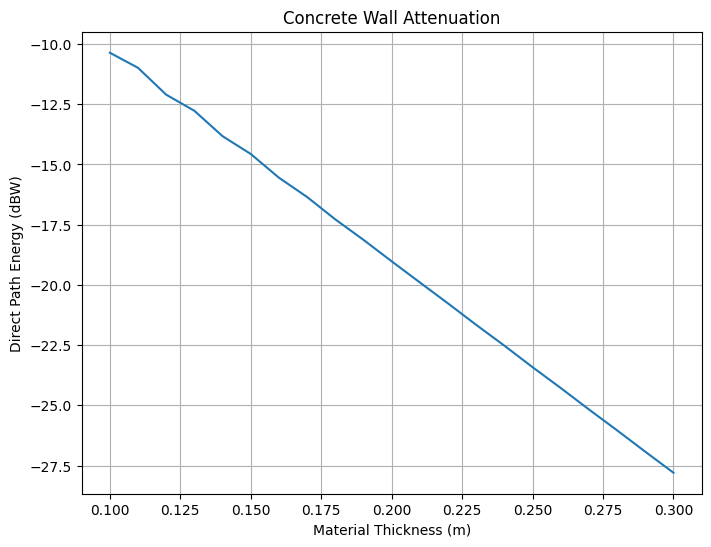

Attenuation slope: -43.02 dB/m
-13.82751897105553 -18.129491101660538


In [33]:
free_loss = 1.1615168e-05 # For 2m

plt.figure(figsize=(8, 6))
plt.plot(0.01 * np.arange(10, 31), 10*np.log10(energy_array / free_loss))
plt.title('Concrete Wall Attenuation')
plt.xlabel('Material Thickness (m)')
plt.ylabel('Direct Path Energy (dBW)')
plt.grid()
plt.show()

slope = (10*np.log10(energy_array[9] / free_loss) - 10*np.log10(energy_array[4] / free_loss)) / 0.1
print(f"Attenuation slope: {slope:.2f} dB/m")
print(10*np.log10(energy_array[4] / free_loss), 10*np.log10(energy_array[9] / free_loss))

In [35]:
### Distance

# Import scene as xml file
scene = load_scene("PropagationConfig1/Propagation.xml")

scene.radio_materials["itu-concrete"].thickness = 0.1

scene.tx_array = PlanarArray(num_rows=1,
                            num_cols=1,
                            vertical_spacing=0.5,
                            horizontal_spacing=0.5,
                            pattern='iso',
                            polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                            num_cols=1,
                            vertical_spacing=0.5,
                            horizontal_spacing=0.5,
                            pattern='iso',
                            polarization='V')

energy_array = np.zeros(20)
for i in range(20):

    r = 0.1 * (i+1)

    tx = Transmitter("tx", [5, -r, 0])
    # tx = Transmitter("tx", [-4, 8, 1])
    scene.add(tx)

    rx1 = Receiver("rx", [5, r, 0])
    scene.add(rx1)

    pathSolver = PathSolver()
    paths = pathSolver(scene=scene, max_depth=1)

    # Channel impulse response of the path
    cir = paths.cir(sampling_frequency=3.5e9,
                    num_time_steps=1,
                    normalize_delays=False)


    delays, magnitudes = util.format_cir(cir)
    delays = delays[0]
    magnitudes = magnitudes[0]

    # Energy of paths
    energies = magnitudes**2
    energy_array[i] = energies[0]

    # Remove the transmitter and receiver for the next iteration
    scene.remove("tx")
    scene.remove("rx")

    

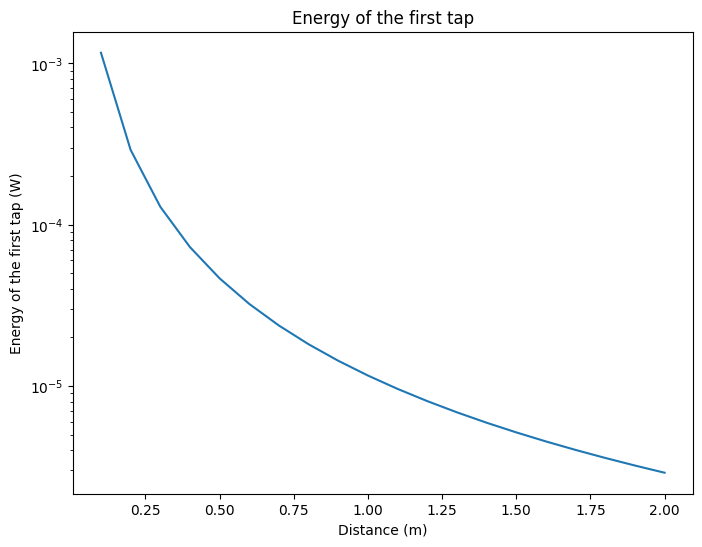

1.0
1.1615167750278488e-05


In [36]:
plt.figure(figsize=(8, 6))
plt.plot(0.1 * np.arange(1, 21), energy_array)
plt.yscale('log')
plt.title('Energy of the first tap')
plt.xlabel('Distance (m)')
plt.ylabel('Energy of the first tap (W)')
plt.show()

print(0.1 * np.arange(1, 21)[9])
print(energy_array[9])

In [42]:
### Distance

# Import scene as xml file
scene = load_scene("PropagationConfig1/Propagation.xml")

scene.radio_materials["itu-concrete"].thickness = 0.1

scene.tx_array = PlanarArray(num_rows=1,
                            num_cols=1,
                            vertical_spacing=0.5,
                            horizontal_spacing=0.5,
                            pattern='iso',
                            polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                            num_cols=1,
                            vertical_spacing=0.5,
                            horizontal_spacing=0.5,
                            pattern='iso',
                            polarization='V')

energy_array = np.zeros(18)
for i in range(18):

    theta = 5 * i
    r = 1
    x = r * np.sin(np.radians(theta)) 
    y = r * np.cos(np.radians(theta))
    # Convert x and y to float
    x = float(x)
    y = float(y)

    tx = Transmitter("tx", [-x, y, 0])
    # tx = Transmitter("tx", [-4, 8, 1])
    scene.add(tx)

    rx1 = Receiver("rx", [x, -y, 0])
    scene.add(rx1)

    pathSolver = PathSolver()
    paths = pathSolver(scene=scene, max_depth=1)

    # Channel impulse response of the path
    cir = paths.cir(sampling_frequency=3.5e9,
                    num_time_steps=1,
                    normalize_delays=False)


    delays, magnitudes = util.format_cir(cir)
    delays = delays[0]
    magnitudes = magnitudes[0]

    # Energy of paths
    energies = magnitudes**2
    energy_array[i] = energies[0]

    # Remove the transmitter and receiver for the next iteration
    scene.remove("tx")
    scene.remove("rx")

    

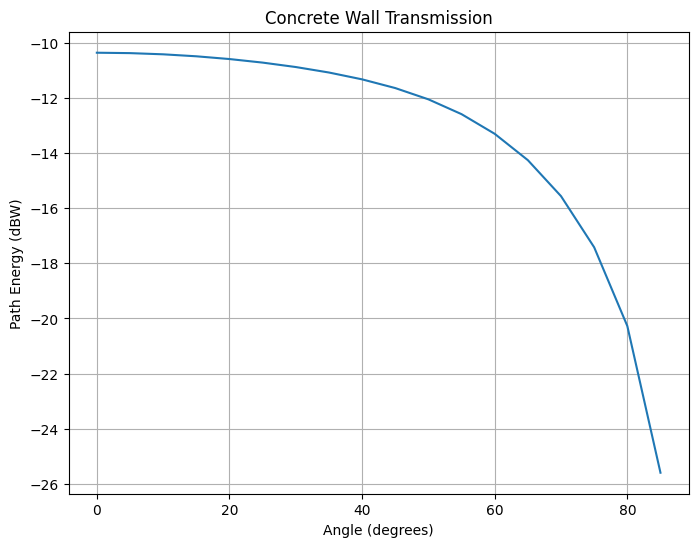

In [44]:
free_loss = 1.1615168e-05 # For 2m

plt.figure(figsize=(8, 6))
plt.plot(5*np.arange(18), 10*np.log10(energy_array / free_loss))
plt.title('Concrete Wall Transmission')
plt.xlabel('Angle (degrees)')
plt.ylabel('Path Energy (dBW)')
plt.grid()
plt.show()